In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Loading the Data
df = pd.read_csv("Zomato_Restaurants_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (7105, 12)


,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,Unnamed: 9,area,local address
0,0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,0,Bellandur,Bellandur
1,1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages",1,"Byresandra,Tavarekere,Madiwala",HSR
2,2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",2,Bannerghatta Road,Bannerghatta Road
3,3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",3,Marathahalli,Marathahalli
4,4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",4,Bellandur,Bellandur


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7105 non-null   int64  
 1   restaurant name        7105 non-null   object 
 2   restaurant type        7105 non-null   object 
 3   rate (out of 5)        7105 non-null   float64
 4   num of ratings         7105 non-null   int64  
 5   avg cost (two people)  7105 non-null   int64  
 6   online_order           7105 non-null   object 
 7   table booking          7105 non-null   object 
 8   cuisines type          7105 non-null   object 
 9   Unnamed: 9             7105 non-null   int64  
 10  area                   7105 non-null   object 
 11  local address          7105 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 666.2+ KB


In [4]:
# Checking for Missing Values
df.isnull().sum()

Unnamed: 0               0
restaurant name          0
restaurant type          0
rate (out of 5)          0
num of ratings           0
avg cost (two people)    0
online_order             0
table booking            0
cuisines type            0
Unnamed: 9               0
area                     0
local address            0
dtype: int64

In [5]:
df.describe()

,Unnamed: 0,rate (out of 5),num of ratings,avg cost (two people),Unnamed: 9
count,7105.000000,7105.000000,7105.000000,7105.000000,7105.000000
mean,3552.000000,3.480619,188.921042,535.952006,3552.000000
std,2051.181164,0.574133,592.171049,463.554352,2051.181164
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1776.000000,3.200000,16.000000,300.000000,1776.000000
50%,3552.000000,3.500000,40.000000,400.000000,3552.000000
75%,5328.000000,3.800000,128.000000,600.000000,5328.000000
max,7104.000000,4.900000,16345.000000,6000.000000,7104.000000


In [6]:
# Data Cleaning

# Renaming columns for easier access
# Dropping unnecessary columns
# Removing duplicates
# Cleaning location column (some have multiple areas listed)
# Extracting primary cuisine from combined cuisine strings
# Detecting outliers in votes using IQR method


In [7]:
# renaming columns for easier access
df.rename(columns={
    'restaurant name': 'name',
    'restaurant type': 'rest_type',
    'rate (out of 5)': 'rate',
    'num of ratings': 'votes',
    'avg cost (two people)': 'approx_cost',
    'table booking': 'book_table',
    'cuisines type': 'cuisines',
    'area': 'location'
}, inplace=True)

# dropping unnamed/irrelevant columns
df.drop(columns=[col for col in df.columns if 'Unnamed' in str(col)], inplace=True)

df.columns

Index(['name', 'rest_type', 'rate', 'votes', 'approx_cost', 'online_order',
       'book_table', 'cuisines', 'location', 'local address'],
      dtype='object')

In [8]:
# some locations have multiple areas like "Byresandra, Tavarekere, Madiwala"
# keeping only the first area for cleaner analysis
df['location'] = df['location'].apply(lambda x: str(x).split(',')[0].strip())

print("Unique locations:", df['location'].nunique())
df['location'].value_counts().head(10)

Unique locations: 30


location
Byresandra           798
Bannerghatta Road    552
Brookefield          477
Brigade Road         464
Indiranagar          455
Electronic City      403
Malleshwaram         402
Kalyan Nagar         384
Bellandur            361
Banashankari         359
Name: count, dtype: int64

In [9]:
# some restaurants have multiple cuisines like "North Indian, Chinese"
# extracting primary cuisine for cleaner analysis
df['primary_cuisine'] = df['cuisines'].apply(lambda x: str(x).split(',')[0].strip())

print("Unique primary cuisines:", df['primary_cuisine'].nunique())
df['primary_cuisine'].value_counts().head(10)

# same for restaurant type - many have combined types like 'Takeaway, Delivery'
df['primary_rest_type'] = df['rest_type'].apply(lambda x: str(x).split(',')[0].strip())
print('Unique primary rest types:', df['primary_rest_type'].nunique())
df['primary_rest_type'].value_counts().head(10)

Unique primary cuisines: 85
Unique primary rest types: 22


primary_rest_type
Quick Bites       2881
Casual Dining     1805
Cafe               462
Delivery           358
Takeaway           307
Dessert Parlor     252
Bakery             197
Beverage Shop      154
Bar                139
Food Court          94
Name: count, dtype: int64

In [10]:
before = len(df)
df.drop_duplicates(inplace=True)
print("Rows before:", before)
print("Rows after:", len(df))
print("Duplicates removed:", before - len(df))

Rows before: 7105
Rows after: 7105
Duplicates removed: 0


In [11]:
# outlier detection in votes using IQR
Q1 = df["votes"].quantile(0.25)
Q3 = df["votes"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["votes"] < Q1 - 1.5*IQR) | (df["votes"] > Q3 + 1.5*IQR)]
print("Outliers detected in votes:", len(outliers))
# keeping them - high votes just means very popular restaurants

Outliers detected in votes: 942


In [12]:
print("Final clean dataset shape:", df.shape)
df.head()

Final clean dataset shape: (7105, 12)


,name,rest_type,rate,votes,approx_cost,online_order,book_table,cuisines,location,local address,primary_cuisine,primary_rest_type
0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,Bellandur,Bellandur,Fast Food,Quick Bites
1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages",Byresandra,HSR,Fast Food,Quick Bites
2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,Cafe,Cafe
3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,Biryani,Casual Dining
4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,BBQ,Casual Dining


In [13]:
# Exploratory Data Analysis

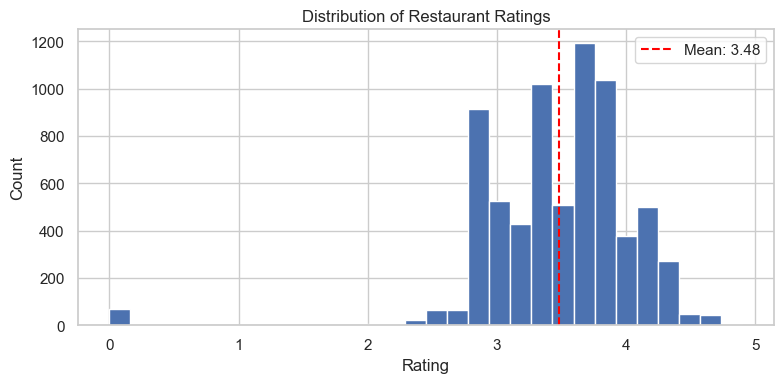

In [14]:
# Rating Distribution
# To see how ratings are spread across all restaurants.

import os
os.makedirs("plots", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["rate"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(df["rate"].mean(), color="red", linestyle="--", label=f"Mean: {df['rate'].mean():.2f}")
ax.set_title("Distribution of Restaurant Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("plots/01_rating_distribution.png", dpi=150)
plt.show()

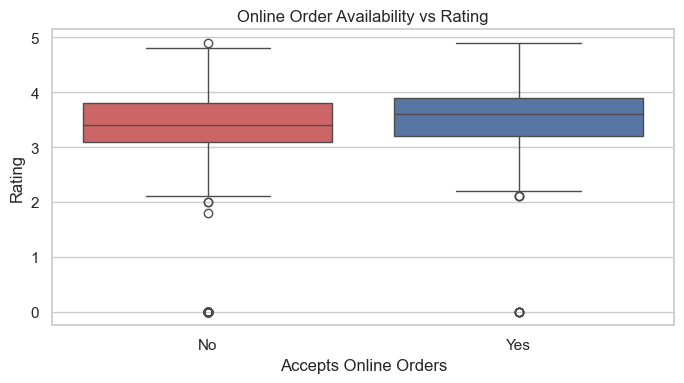

Avg rating - Online Order YES: 3.55
Avg rating - Online Order NO : 3.41


In [15]:
# Does Online Ordering Affect Ratings?
# Checking if restaurants that accept online orders have different ratings.

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="online_order", y="rate", palette=["#DD5555", "#4C72B0"], ax=ax)
ax.set_title("Online Order Availability vs Rating")
ax.set_xlabel("Accepts Online Orders")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.savefig("plots/02_online_order_vs_rating.png", dpi=150)
plt.show()

print("Avg rating - Online Order YES:", round(df[df["online_order"]=="Yes"]["rate"].mean(), 2))
print("Avg rating - Online Order NO :", round(df[df["online_order"]=="No"]["rate"].mean(), 2))

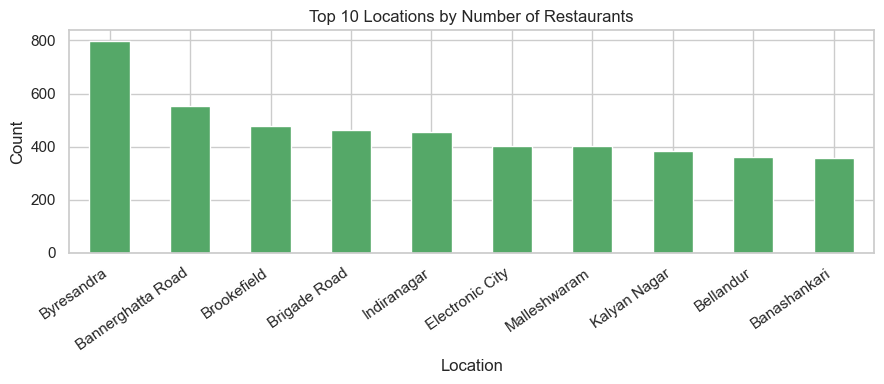

In [16]:
# Which Areas Have the Most Restaurants?

top_locs = df["location"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
top_locs.plot(kind="bar", color="#55A868", edgecolor="white", ax=ax)
ax.set_title("Top 10 Locations by Number of Restaurants")
ax.set_xlabel("Location")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig("plots/03_top_locations.png", dpi=150)
plt.show()

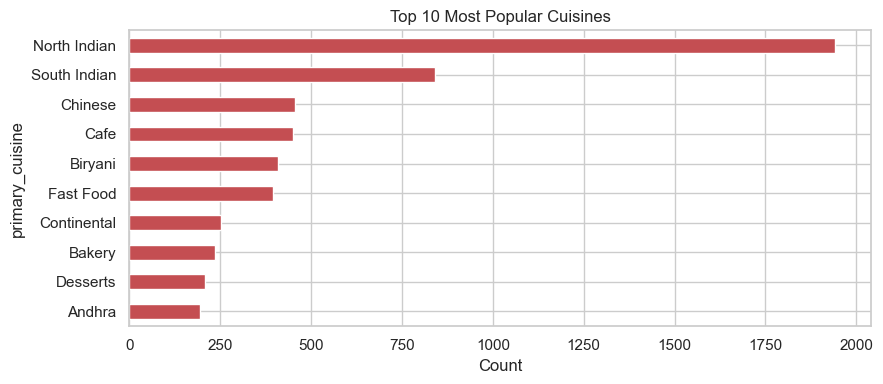

In [17]:
# Most Popular Cuisines

top_cuisines = df["primary_cuisine"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
top_cuisines.plot(kind="barh", color="#C44E52", edgecolor="white", ax=ax)
ax.set_title("Top 10 Most Popular Cuisines")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plots/04_cuisine_popularity.png", dpi=150)
plt.show()

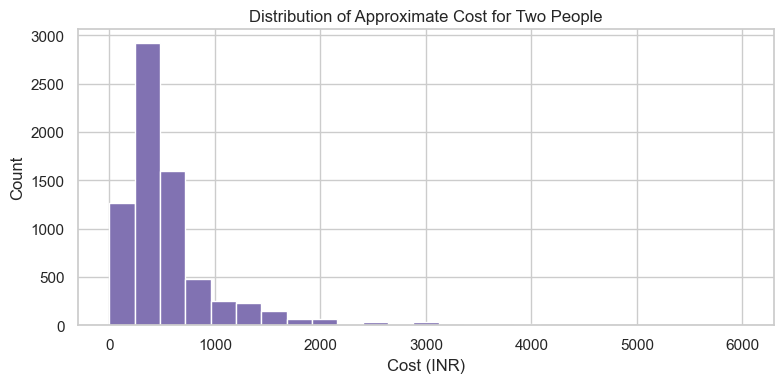

Average cost for two: 535.95
Median cost for two : 400.0


In [18]:
# How Much Does Dining Cost?
# Looking at approximate cost for two people across restaurants.

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["approx_cost"], bins=25, color="#8172B2", edgecolor="white")
ax.set_title("Distribution of Approximate Cost for Two People")
ax.set_xlabel("Cost (INR)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("plots/05_cost_distribution.png", dpi=150)
plt.show()

print("Average cost for two:", round(df["approx_cost"].mean(), 2))
print("Median cost for two :", round(df["approx_cost"].median(), 2))

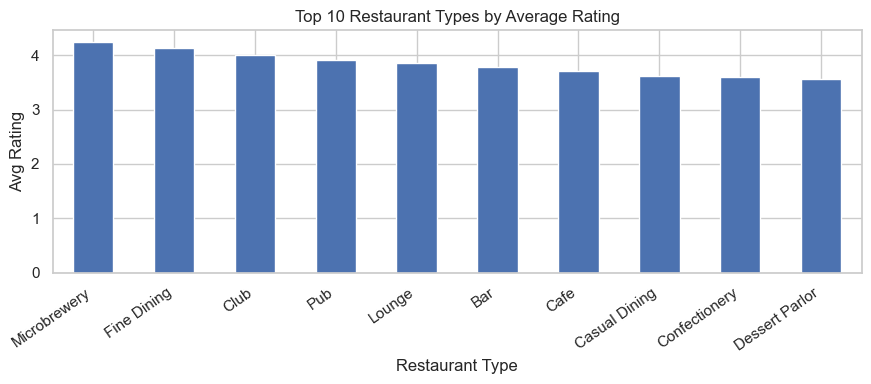

In [19]:
# Which Restaurant Type Gets Better Ratings?

avg_rating_type = df.groupby("primary_rest_type")["rate"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 4))
avg_rating_type.plot(kind="bar", color="#4C72B0", edgecolor="white", ax=ax)
ax.set_title("Top 10 Restaurant Types by Average Rating")
ax.set_xlabel("Restaurant Type")
ax.set_ylabel("Avg Rating")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig("plots/06_rest_type_vs_rating.png", dpi=150)
plt.show()

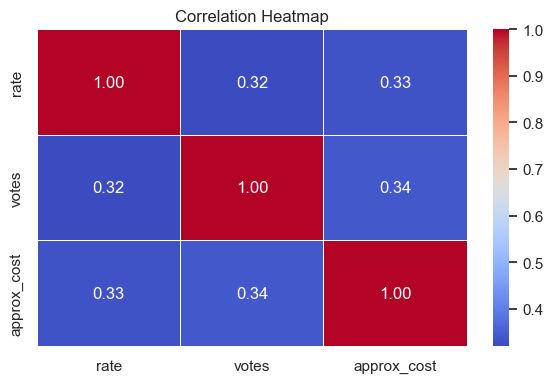

In [20]:
# Correlation Between Numeric Features
# Checking if there's any relationship between rating, votes, and cost.

numeric_df = df[["rate", "votes", "approx_cost"]]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/07_correlation_heatmap.png", dpi=150)
plt.show()

## Key Insights

1. **Ratings** - Most restaurants (78.7%) are rated between 3.0 and 4.2. 
The average rating is 3.48, suggesting moderate satisfaction overall 
across Bangalore.

2. **Online Ordering** - Restaurants that accept online orders have a 
slightly higher average rating (3.55) compared to those that don't (3.41).
About 52.5% of restaurants offer online ordering.

3. **Location** - Byresandra, Bannerghatta Road and Brookefield have the 
highest number of restaurants, indicating strong dining demand in these areas.

4. **Cuisines** - North Indian cuisine is by far the most popular (1943 
restaurants), followed by South Indian and Chinese. This reflects 
Bangalore's diverse food culture.

5. **Pricing** - Average cost for two people is ₹536, with median at ₹400. 
About 68% of restaurants fall in the ₹200–₹600 range, showing 
budget-friendly dining dominates.

6. **Votes vs Rating** - There is a moderate positive correlation (0.32) 
between votes and rating, and also between cost and rating (0.33). 
Higher-priced restaurants tend to get better ratings and more engagement.
